In [27]:
import cv2
import os
import numpy as np
import random
import matplotlib.pyplot as plt

from skimage.feature import local_binary_pattern
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


In [28]:
DATA_DIR = "data"

yes_folder = os.path.join(DATA_DIR, "canceroase")
no_folder = os.path.join(DATA_DIR, "sanatoase")


In [29]:
print("Imagini canceroase:", len(os.listdir(yes_folder)))
print("Imagini sanatoase:", len(os.listdir(no_folder)))

Imagini canceroase: 207
Imagini sanatoase: 208


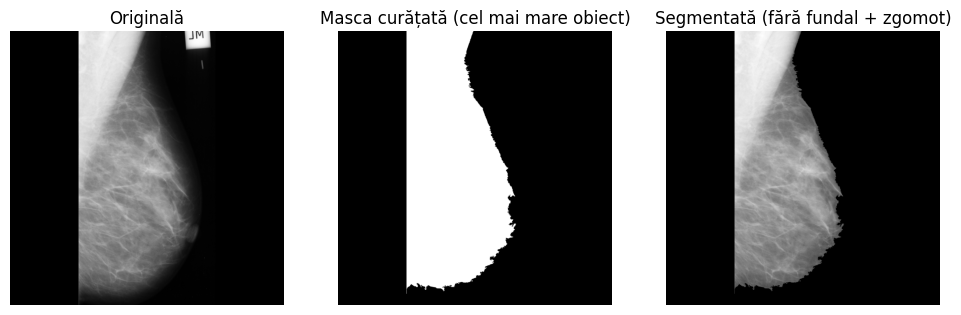

In [30]:
# alegem random o imagine dintr-un folder

folder_choice = random.choice([yes_folder, no_folder])
file_choice = random.choice(os.listdir(folder_choice))

img_path = os.path.join(folder_choice, file_choice)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# prag Otsu
_, mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# găsim contururile obiectelor albe
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15,15))
mask_clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# selectăm cel mai mare contur (sânul)
largest_contour = max(contours, key=cv2.contourArea)

# creăm o mască nouă doar cu cel mai mare obiect
clean_mask = np.zeros_like(mask)
cv2.drawContours(clean_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

# aplicăm masca curățată pe imagine
segmented = cv2.bitwise_and(img, img, mask=clean_mask)

# afișare rezultate
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Originală")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(clean_mask, cmap='gray')
plt.title("Masca curățată (cel mai mare obiect)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(segmented, cmap='gray')
plt.title("Segmentată (fără fundal + zgomot)")
plt.axis("off")

plt.show()




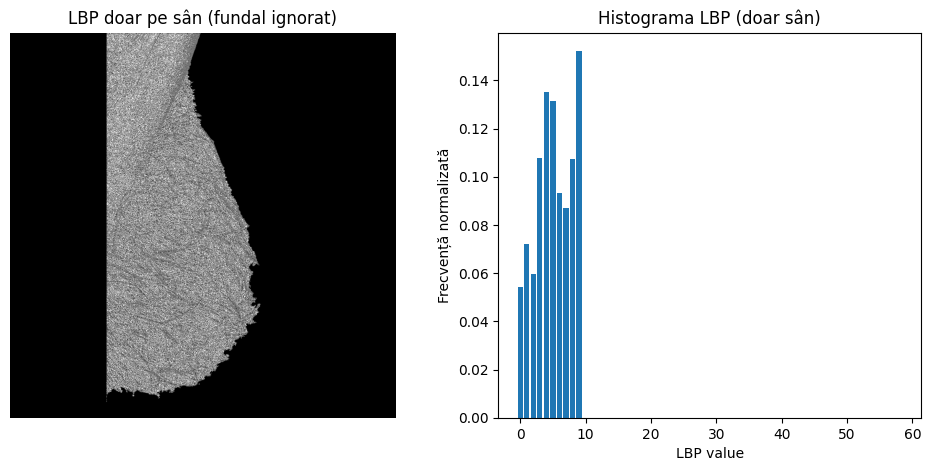

In [31]:
# parametri LBP
radius = 1
n_points = 8 * radius
method = 'uniform'  # LBP uniform

# aplicăm LBP pe întreaga imagine segmentată
lbp = local_binary_pattern(segmented, n_points, radius, method)

# păstrăm doar pixelii care aparțin sânului (masca curățată)
lbp_masked = np.where(clean_mask > 0, lbp, 0)

# histograma LBP pe pe sân
n_bins = 59
hist, _ = np.histogram(lbp_masked[clean_mask > 0],
                       bins=np.arange(0, n_bins+1),
                       range=(0, n_bins),
                       density=True)

# afișare
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(lbp_masked, cmap='gray')
plt.title("LBP doar pe sân (fundal ignorat)")
plt.axis("off")

plt.subplot(1,2,2)
plt.bar(range(n_bins), hist)
plt.title("Histograma LBP (doar sân)")
plt.xlabel("LBP value")
plt.ylabel("Frecvență normalizată")
plt.show()


Număr celule păstrate: 301
Dimensiunea vectorului de caracteristici: 17759


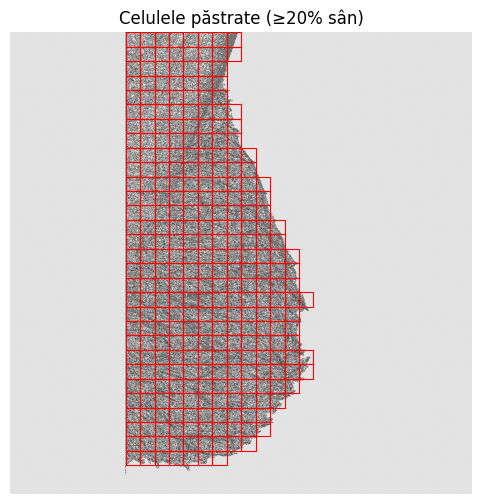

In [32]:

cell_size = 32

h, w = lbp.shape
selected_hists = []
coords = []

for i in range(0, h, cell_size):
    for j in range(0, w, cell_size):
        # decupăm celula
        cell_lbp = lbp[i:i+cell_size, j:j+cell_size]
        cell_mask = clean_mask[i:i+cell_size, j:j+cell_size]

        if cell_lbp.shape[0] != cell_size or cell_lbp.shape[1] != cell_size:
            continue  # sărim peste marginile incomplete

        # procent de sân în celulă
        breast_ratio = np.sum(cell_mask > 0) / (cell_size * cell_size)

        if breast_ratio >= 0.2:  # păstrăm doar celulele cu ≥20% sân
            hist, _ = np.histogram(cell_lbp[cell_mask > 0].ravel(),
                                   bins=np.arange(0, n_bins+1),
                                   range=(0, n_bins),
                                   density=True)
            selected_hists.append(hist)
            coords.append((i, j))

feature_vector = np.concatenate(selected_hists)

print(f"Număr celule păstrate: {len(selected_hists)}")
print(f"Dimensiunea vectorului de caracteristici: {feature_vector.shape[0]}")

# vizualizare celule păstrate pe imagine
plt.figure(figsize=(6,6))
plt.imshow(lbp, cmap="gray")
for (i, j) in coords:
    rect = plt.Rectangle((j, i), cell_size, cell_size,
                         edgecolor="red", facecolor="none", linewidth=0.8)
    plt.gca().add_patch(rect)
plt.title("Celulele păstrate (≥20% sân)")
plt.axis("off")
plt.show()


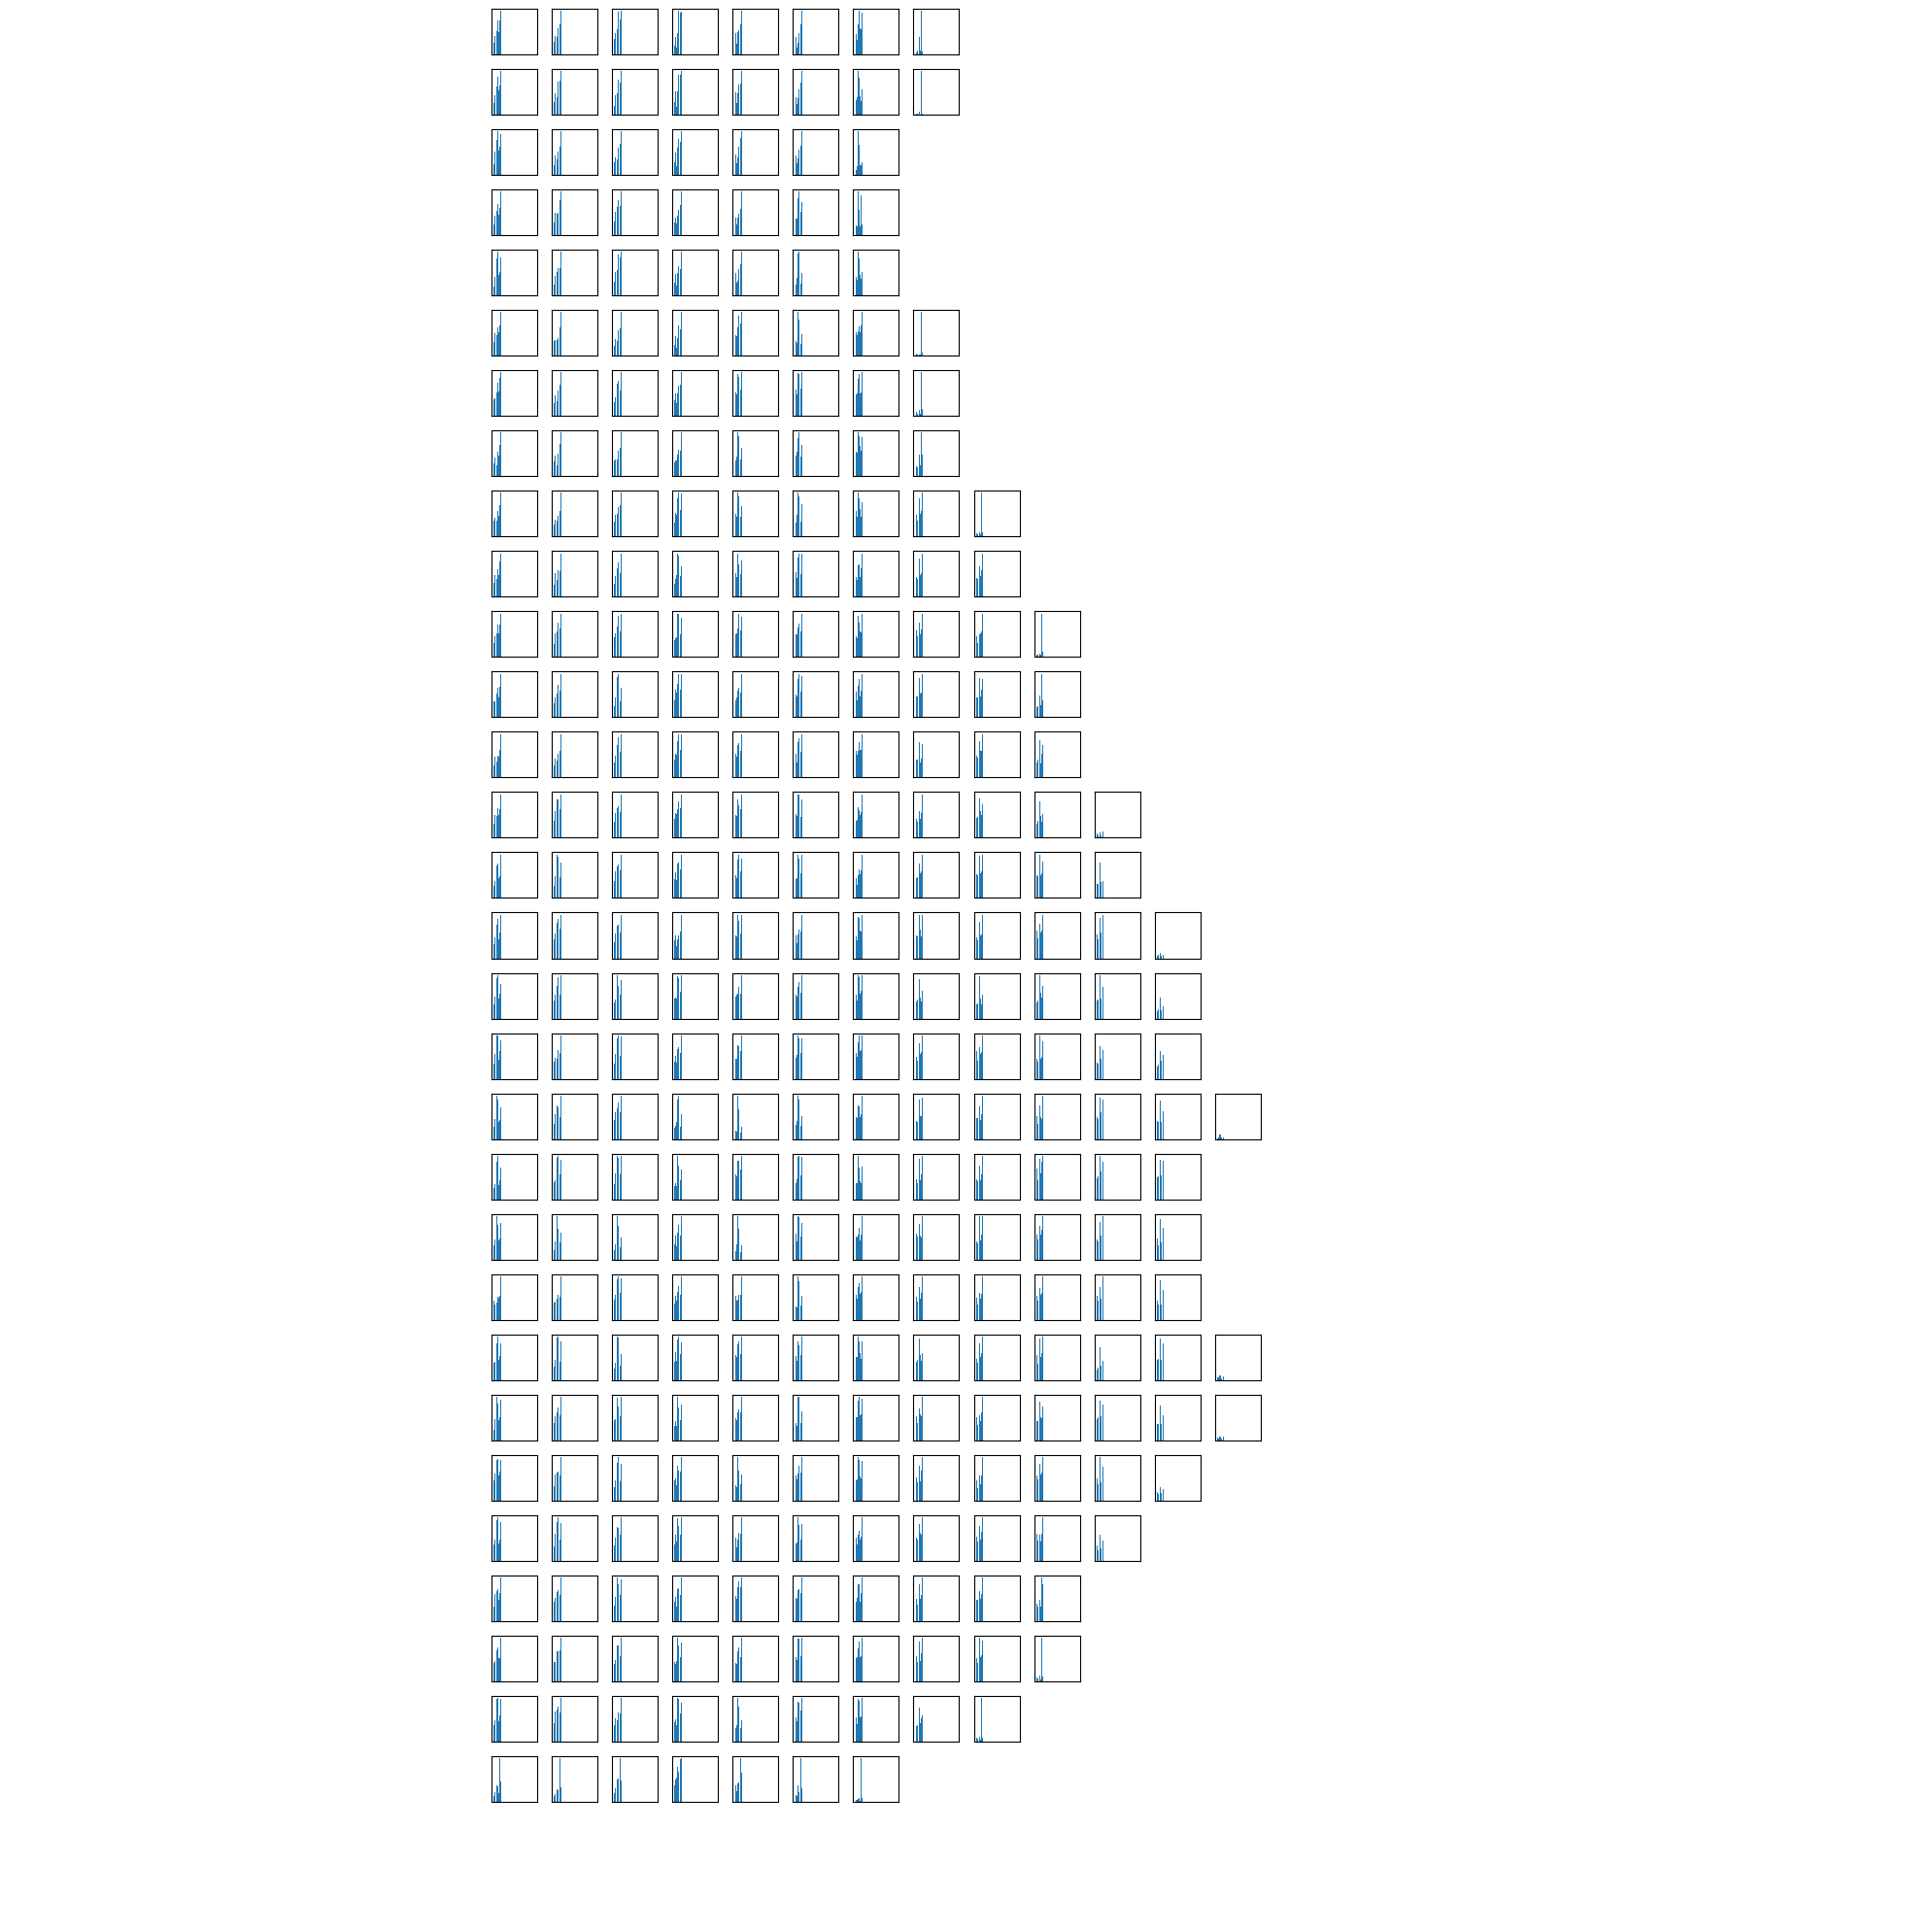

In [33]:


# parametrii grid

h, w = segmented.shape
n_cells_x = w // cell_size
n_cells_y = h // cell_size

fig, axes = plt.subplots(n_cells_y, n_cells_x, figsize=(20, 20))

for i in range(n_cells_y):
    for j in range(n_cells_x):
        y0, y1 = i * cell_size, (i + 1) * cell_size
        x0, x1 = j * cell_size, (j + 1) * cell_size

        cell = segmented[y0:y1, x0:x1]
        cell_mask = clean_mask[y0:y1, x0:x1]

        if np.sum(cell_mask > 0) > 0.2 * cell_mask.size:  # păstrăm doar celulele cu sân
            lbp_cell = local_binary_pattern(cell, n_points, radius, method="uniform")
            hist, _ = np.histogram(lbp_cell.ravel(), bins=np.arange(n_bins+1), range=(0, n_bins))
            hist = hist.astype("float")
            hist /= (hist.sum() + 1e-6)

            axes[i, j].bar(range(n_bins), hist)
        else:
            axes[i, j].axis("off")

        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.tight_layout()
plt.show()


In [34]:
features = []   # lista vectorilor de 59 dimensiuni (câte unul per celulă)

for i in range(n_cells_y):
    for j in range(n_cells_x):
        y0, y1 = i * cell_size, (i + 1) * cell_size
        x0, x1 = j * cell_size, (j + 1) * cell_size

        cell = segmented[y0:y1, x0:x1]
        cell_mask = clean_mask[y0:y1, x0:x1]

        # verificăm dacă e celulă validă (nu doar fundal)
        if np.sum(cell_mask > 0) > 0.2 * cell_mask.size: #proportia de tesut care apartin sanului in celula
                                                        #pastreaza doar celulele cu >=20% san
            lbp_cell = local_binary_pattern(cell, n_points, radius, method="uniform")
            hist, _ = np.histogram(lbp_cell.ravel(), bins=np.arange(n_bins+1), range=(0, n_bins))
            hist = hist.astype("float")
            hist /= (hist.sum() + 1e-6)  # normalizare
            features.append(hist)

# transformăm în array (nr_celule x 59)
features = np.array(features)
print("Dimensiunea vectorilor de caracteristici per celulă:", features.shape)


Dimensiunea vectorilor de caracteristici per celulă: (301, 59)


In [35]:
n_bins = n_points * (n_points - 1) + 3  # 59 dimensiunea vectorului


def process_image(img_path):
    # citire imagine
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None

    # prag Otsu
    _, mask = cv2.threshold(
        img,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # găsim contururile
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None

    # cel mai mare contur = san
    largest_contour = max(contours, key=cv2.contourArea)

    clean_mask = np.zeros_like(mask)

    cv2.drawContours(
        clean_mask,
        [largest_contour],
        -1,
        255,
        thickness=cv2.FILLED
    )

    # aplic masca
    segmented = cv2.bitwise_and(
        img,
        img,
        mask=clean_mask
    )

    # calculez LBP uniform
    lbp = local_binary_pattern(
        segmented,
        n_points,
        radius,
        method
    )

    # impart imaginea in celule si calculez histograme
    h, w = img.shape
    features = []

    for y in range(0, h, cell_size):
        for x in range(0, w, cell_size):

            cell = lbp[
                y:y + cell_size,
                x:x + cell_size
            ]

            cell_mask = clean_mask[
                y:y + cell_size,
                x:x + cell_size
            ]

            # evităm celulele goale
            if cell_mask.size == 0:
                continue

            # procentul de san din celula
            breast_ratio = np.sum(cell_mask > 0) / cell_mask.size

            # pastram doar celulele cu cel putin 20% san
            if breast_ratio < 0.2:
                continue

            hist, _ = np.histogram(
                cell[cell_mask > 0],
                bins=np.arange(0, n_bins + 1),
                range=(0, n_bins),
                density=True
            )

            features.append(hist)

    # daca nu s-au extras caracteristici
    if len(features) == 0:
        return None

    return np.array(features)


# aplicăm pe toate imaginile din set
all_features = []
labels = []  # 1 pentru canceroase, 0 pentru sănătoase

for folder, label in [(yes_folder, 1), (no_folder, 0)]:

    for filename in tqdm(
        os.listdir(folder),
        desc=f"Procesez {folder}"
    ):

        img_path = os.path.join(folder, filename)

        feats = process_image(img_path)

        if feats is not None and len(feats) > 0:
            all_features.append(feats)
            labels.append(label)


print(
    "Am extras caracteristici pentru",
    len(all_features),
    "imagini."
)


Procesez data/sanatoase: 100%|██████████| 208/208 [00:54<00:00,  3.82it/s]

Am extras caracteristici pentru 415 imagini.


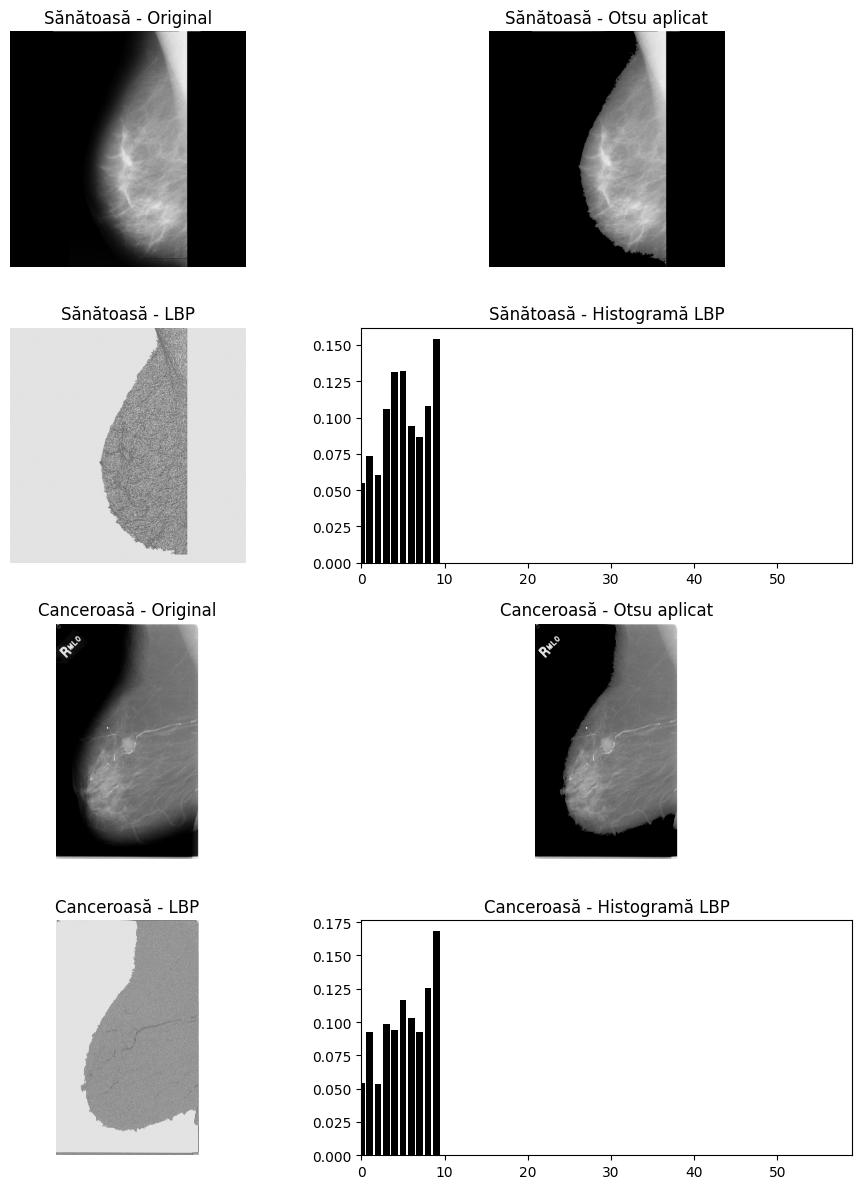

In [36]:


# ---- Funcție vizualizare pentru o imagine ----
def visualize_image(img_path, title=""):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # prag Otsu
    _, mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest_contour = max(contours, key=cv2.contourArea)
    clean_mask = np.zeros_like(mask)
    cv2.drawContours(clean_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

    # imagini segmentate
    segmented = cv2.bitwise_and(img, img, mask=clean_mask)
    otsu_applied = cv2.bitwise_and(img, img, mask=mask)

    # LBP pe sân
    lbp = local_binary_pattern(segmented, n_points, radius, method)

    # histograma globală pe sân
    hist, _ = np.histogram(lbp[clean_mask > 0],
                           bins=np.arange(0, n_bins+1),
                           range=(0, n_bins),
                           density=True)

    return img, otsu_applied, lbp, hist, title

# ---- Alegem câte o imagine random din fiecare folder ----
healthy_path = os.path.join(no_folder, random.choice(os.listdir(no_folder)))
cancer_path  = os.path.join(yes_folder, random.choice(os.listdir(yes_folder)))

healthy_data = visualize_image(healthy_path, "Sănătoasă")
cancer_data  = visualize_image(cancer_path, "Canceroasă")

# ---- Afișare grid 4x2 ----
fig, axes = plt.subplots(4, 2, figsize=(10, 12))  # 4 rânduri, 2 coloane
images = [healthy_data, cancer_data]

for idx, (img, otsu_applied, lbp, hist, title) in enumerate(images):
    row_offset = idx * 2  # 0 pentru sănătoasă, 2 pentru canceroasă

    # Rând 1: Original și Otsu aplicat
    axes[row_offset, 0].imshow(img, cmap="gray")
    axes[row_offset, 0].set_title(f"{title} - Original")
    axes[row_offset, 0].axis("off")

    axes[row_offset, 1].imshow(otsu_applied, cmap="gray")
    axes[row_offset, 1].set_title(f"{title} - Otsu aplicat")
    axes[row_offset, 1].axis("off")

    # Rând 2: LBP și Histogramă
    axes[row_offset + 1, 0].imshow(lbp, cmap="gray")
    axes[row_offset + 1, 0].set_title(f"{title} - LBP")
    axes[row_offset + 1, 0].axis("off")

    axes[row_offset + 1, 1].bar(range(len(hist)), hist, color="black")
    axes[row_offset + 1, 1].set_title(f"{title} - Histogramă LBP")
    axes[row_offset + 1, 1].set_xlim([0, n_bins])

plt.tight_layout()
plt.show()


In [37]:
X_img = []
y_img = []

for feats, label in zip(all_features, labels):
    # feats = (nr_celule_valide, 59)
    # agregăm pe imagine -> media histogramelor
    img_features = np.mean(feats, axis=0)   # (59,)

    X_img.append(img_features)
    y_img.append(label)

X_img = np.array(X_img)   # (num_imagini, 59)
y_img = np.array(y_img)   # (num_imagini,) eticheta

print("Dimensiunea X_img:", X_img.shape)
print("Dimensiunea y_img:", y_img.shape)


Dimensiunea X_img: (415, 59)
Dimensiunea y_img: (415,)


In [38]:
X = []
y = []

for feats, label in zip(all_features, labels):
    for cell_hist in feats:
        X.append(cell_hist)   # fiecare histogramă LBP (59 dim)
        y.append(label)       # eticheta imaginii

X = np.array(X)
y = np.array(y)

print("Dimensiunea X:", X.shape)  # (num_total_celule, 59)
print("Dimensiunea y:", y.shape)


Dimensiunea X: (731725, 59)
Dimensiunea y: (731725,)


In [ ]:

#degree=3 polinom de grad 3, poate modela frontiere de decizie neliniare
#gamma =0,5 controleaza cat de mult influenteaza fiecare punct decizia,
#da voie modelului sa fie suficient dintre maximizarea marginilor de separare si minimizarea erorilor de clasificare
#C=1, parametru de regularizare; un C mare penalizeaza erorile, un C mic permite mai multe erori


clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="poly", degree=3, gamma=0.5, C=1.0, probability=True)
)

In [40]:
# împărțire train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_img, y_img, test_size=0.2, random_state=42, stratify=y_img
)


In [41]:
# antrenare
clf.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(gamma=0.5, kernel='poly', probability=True))])

Acuratețe pe datele de antrenare: 0.7380
Acuratețe pe datele de test: 0.7229

Raport pe datele de test:

Clasa 0: Precision=0.65, Recall=1.00, F1=0.79, Support=42.0
Clasa 1: Precision=1.00, Recall=0.44, F1=0.61, Support=41.0


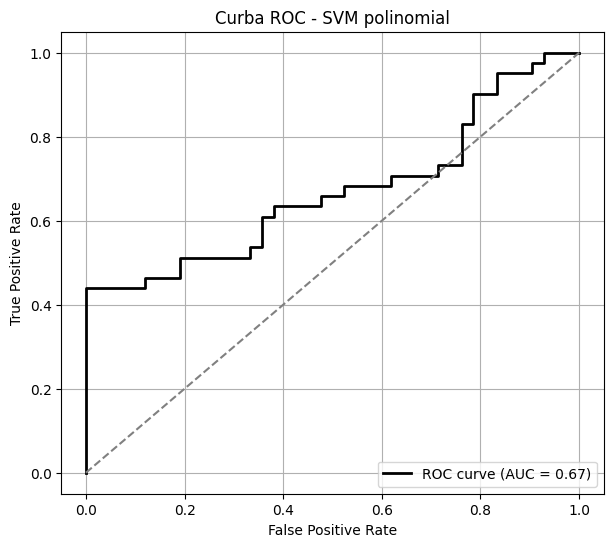

In [42]:
# Predicții pe train și test
y_train_pred = clf.predict(X_train)
y_test_pred  = clf.predict(X_test)

# Acuratețe
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

print(f"Acuratețe pe datele de antrenare: {train_acc:.4f}")
print(f"Acuratețe pe datele de test: {test_acc:.4f}\n")

report = classification_report(y_test, y_test_pred, output_dict=True)
print("Raport pe datele de test:\n")
for cls in ['0', '1']:
    precision = report[cls]['precision']
    recall    = report[cls]['recall']
    f1        = report[cls]['f1-score']
    support   = report[cls]['support']
    print(f"Clasa {cls}: Precision={precision:.2f}, Recall={recall:.2f}, F1={f1:.2f}, Support={support}")

# ROC și AUC

y_score = clf.decision_function(X_test)  #scor de decizie
                                         #scor mare pozitiv → modelul e încrezător că e clasa pozitivă (1 = canceroasă).
                                         #scor negativ → modelul înclină spre clasa negativă (0 = sănătoasă).


fpr, tpr, thresholds = roc_curve(y_test, y_score)   #rata de alarme false (frp) si rata de detectii corecte (trp)
roc_auc = auc(fpr, tpr) #AUC

# Afișare grafic
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='black', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curba ROC - SVM polinomial')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [44]:
new_img_path = os.path.join(yes_folder, os.listdir(yes_folder)[0])

features_new = process_image(new_img_path)

if features_new is None or len(features_new) == 0:
    print("Imaginea nu a putut fi procesată.")
else:
    img_features_new = np.mean(features_new, axis=0).reshape(1, -1)

    pred_class = clf.predict(img_features_new)[0]

    if pred_class == 1:
        print("Predicție: Canceroasă")
    else:
        print("Predicție: Sănătoasă")


Predicție: Sănătoasă
